# Rabi Oscillations

## Overview

In this notebook we demonstrate Rabi oscillations using the circuit model of quantum computing.

We will:

1. Review the theoretical expression for the excited-state probability.
2. Implement a single-qubit rotation $R_x(\theta)$.
3. Compare analytic, exact simulator, and finite-shot results.
4. Explore T1 relaxation and T2 dephasing with noisy circuits.
5. Simulate off-resonant Rabi oscillations using detuning.

The goal is to connect the physical concept of driven two-level dynamics with its circuit-level implementation.

## Physical Background

Rabi oscillations describe the coherent oscillation of population between the ground and excited states of a two-level quantum system under a resonant drive. In the rotating frame, the evolution of a driven two-level system can be represented as a rotation generated by a single-qubit rotation gate.

If the qubit starts in the ground state and is driven resonantly, the probability of measuring the excited state oscillates as

$P(|1\rangle) = \sin^2(\theta / 2)$

where $\theta$ is the rotation angle induced by the drive. For a constant drive strength $\Omega$, the rotation angle is proportional to time, $\theta = \Omega t$. Sweeping $\theta$ therefore simulates the time evolution of a driven two-level system and produces Rabi oscillations.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from braket.devices import LocalSimulator
from braket.circuits import Circuit, ResultType

from braket.experimental.algorithms.rabi_oscillations import (
    excited_state_probability,
    rabi_circuit,
    rabi_probability,
    rabi_simulated_dynamics,
)


## Constructing the Circuit

We simulate Rabi oscillations using single-qubit rotations. A rotation around the x-axis corresponds to a resonant drive applied to the qubit.

For a given rotation angle θ, we apply an Rx(θ) gate to the qubit and then measure it. Measuring the qubit after the rotation allows us to estimate the probability of finding the qubit in the excited state, which corresponds to the excited-state population in the Rabi oscillation model.

By sweeping the rotation angle θ over a range of values, we can simulate the oscillatory behavior of the excited-state population.

In [3]:
theta_example = np.pi / 3
circ = rabi_circuit(theta_example)
print(circ.diagram())


T  : │     0      │
      ┌──────────┐ 
q0 : ─┤ Rx(1.05) ├─
      └──────────┘ 
T  : │     0      │


## Sweeping the Rotation Angle

We vary $\theta$ from $0$ to $2\pi$ and compute the expected analytic probability.

In [4]:
# Sweep angles from 0 to 2π
thetas = np.linspace(0, 2 * np.pi, 101)

# Analytic prediction
p1_analytic = np.array([rabi_probability(theta) for theta in thetas])

## Ideal Simulation (Exact Probability)

Using the simulator in analytic mode (`shots=0`), we compute the exact excited-state probability.

In [5]:
device = LocalSimulator()

def p1_from_result_type(theta: float) -> float:
    circ = rabi_circuit(theta)
    circ.add_result_type(ResultType.Probability(target=[0]))
    task = device.run(circ, shots=0)  # analytic mode
    result = task.result()
    probs = result.result_types[0].value  # [P(|0>), P(|1>)]
    return float(probs[1])

p1_sim_exact = np.array([p1_from_result_type(theta) for theta in thetas])

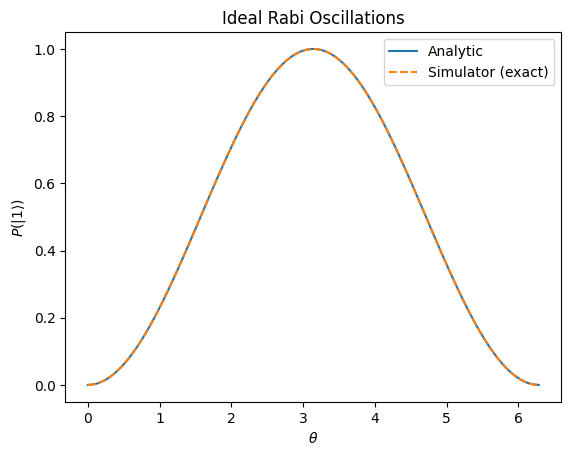

In [6]:
plt.figure()
plt.plot(thetas, p1_analytic, label="Analytic")
plt.plot(thetas, p1_sim_exact, linestyle="--", label="Simulator (exact)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Ideal Rabi Oscillations")
plt.legend()
plt.show()

### Interpretation

The simulator result matches the analytic curve exactly. This confirms that the circuit correctly implements the rotation $R_x(\theta)$ and reproduces ideal Rabi oscillations.

## Sampled Simulation (Finite Shots)

In practice, measurements are sampled. We now estimate the probability using a finite number of shots.

In [7]:
def p1_from_sampling(theta: float, shots: int = 1000) -> float:
    circ = rabi_circuit(theta)
    task = device.run(circ, shots=shots)
    result = task.result()
    counts = result.measurement_counts  # dict like {"0": n0, "1": n1}
    n1 = counts.get("1", 0)
    return n1 / shots

shots = 1000
p1_sim_sampled = np.array([p1_from_sampling(theta, shots=shots) for theta in thetas])

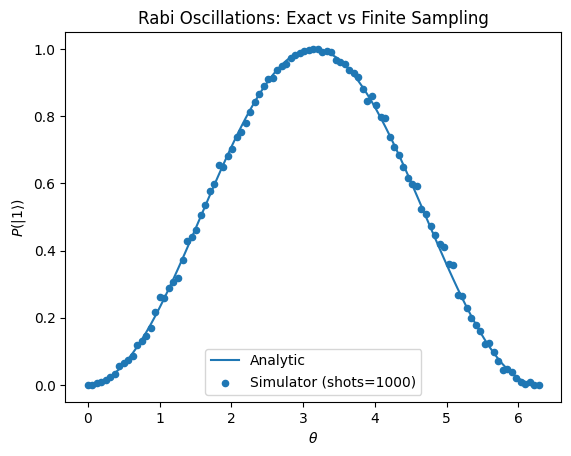

In [8]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
plt.scatter(thetas, p1_sim_sampled, label=f"Simulator (shots={shots})", s=20)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations: Exact vs Finite Sampling")
plt.legend()
plt.show()

### Interpretation

With a finite number of shots, the estimated probabilities fluctuate around the ideal curve due to sampling noise. Increasing the number of shots would reduce these fluctuations and produce estimates closer to the underlying probability curve.

## T1 Relaxation: Single Damping Channel

We first model a two-level system undergoing Rabi oscillations under T1 relaxation. After applying the rotation $R_x(\theta)$, we apply a single amplitude damping channel.

This model does not represent a full time-resolved T1 experiment. Instead, it demonstrates how an amplitude damping channel changes the measured excited-state population in a Rabi-oscillation circuit.

In [9]:
device_dm = LocalSimulator("braket_dm")

In [ ]:
gamma_values_t1_simple = [0.02, 0.1, 0.5]

p1_t1_simple = {
    gamma: np.array(
        [
            excited_state_probability(
                rabi_simulated_dynamics(theta, gamma_t1=gamma),
                device_dm,
            )
            for theta in thetas
        ]
    )
    for gamma in gamma_values_t1_simple
}

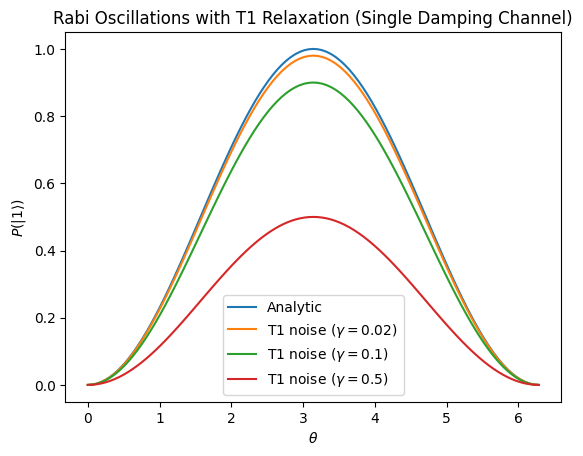

In [11]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
for gamma in gamma_values_t1_simple:
    plt.plot(thetas, p1_t1_simple[gamma], label=fr"T1 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T1 Relaxation (Single Damping Channel)")
plt.legend()
plt.show()

### Interpretation

In this simple model, T1 relaxation reduces the amplitude of the Rabi oscillation. For small $\gamma$, the effect is weak, while for large $\gamma$ the excited-state population is strongly suppressed.

This is a useful first approximation, but it does not yet describe relaxation acting continuously during the driven evolution.

## T1 Relaxation: Stepwise Model

We now use a more realistic model in which the drive and the relaxation act repeatedly throughout the evolution.

To approximate continuous-time dynamics, we divide the total rotation into many small steps. After each small rotation, we apply a small amplitude damping channel. This allows the coherent drive and the T1 process to compete during the evolution.

In [ ]:
thetas_multi_period = np.linspace(0, 8 * np.pi, 300)
gamma_values_t1_stepwise = [0.02, 0.1, 0.5]
p1_analytic = np.array([rabi_probability(theta) for theta in thetas_multi_period])

p1_t1_stepwise = {
    gamma: np.array(
        [
            excited_state_probability(
                rabi_simulated_dynamics(theta, gamma_t1=gamma, dtheta=0.1),
                device_dm,
            )
            for theta in thetas_multi_period
        ]
    )
    for gamma in gamma_values_t1_stepwise
}

### Comparing Single-Channel and Stepwise T1 Models

The single-channel model applies one amplitude damping channel after the full $R_x(\theta)$ rotation. This shows how the amplitude damping channel changes the excited-state population, but the damping strength is fixed and does not scale with the rotation angle.

The stepwise model treats the rotation angle as proportional to elapsed time. The total rotation is divided into small steps, and after each small rotation we apply amplitude damping with strength proportional to the step size. In this model, relaxation accumulates as the total rotation angle increases.

This comparison separates two ideas: a single circuit-level damping operation versus a stepwise approximation to T1 relaxation during driven evolution.

In [ ]:
p1_t1_simple_multi_period = {
    gamma: np.array(
        [
            excited_state_probability(
                rabi_simulated_dynamics(theta, gamma_t1=gamma),
                device_dm,
            )
            for theta in thetas_multi_period
        ]
    )
    for gamma in gamma_values_t1_stepwise
}


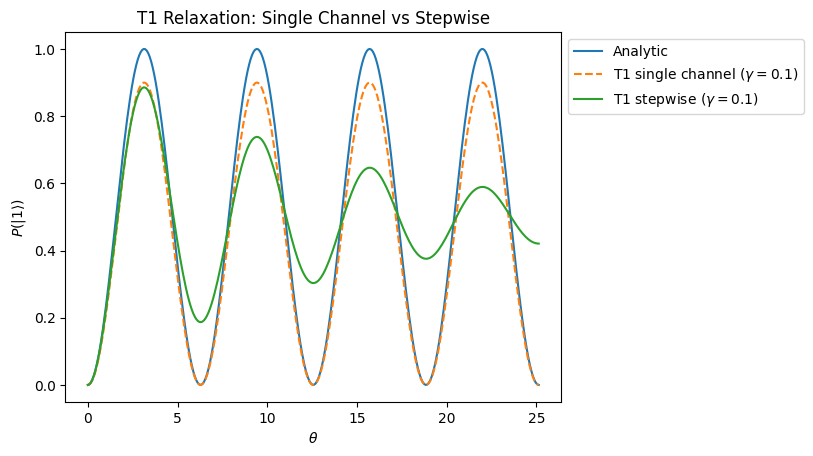

In [27]:
gamma_compare = 0.1

plt.figure()

plt.plot(thetas_multi_period, p1_analytic, label="Analytic")
plt.plot(
    thetas_multi_period,
    p1_t1_simple_multi_period[gamma_compare],
    linestyle="--",
    label=fr"T1 single channel ($\gamma={gamma_compare}$)",
)
plt.plot(
    thetas_multi_period,
    p1_t1_stepwise[gamma_compare],
    label=fr"T1 stepwise ($\gamma={gamma_compare}$)",
)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("T1 Relaxation: Single Channel vs Stepwise")

plt.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=True)

plt.show()

### Stepwise T1 Relaxation for Different Noise Strengths

After comparing the two modeling approaches, we now keep the stepwise model and vary the T1 relaxation strength.

As the damping strength increases, relaxation suppresses the oscillations more strongly and reduces the excited-state population over time.

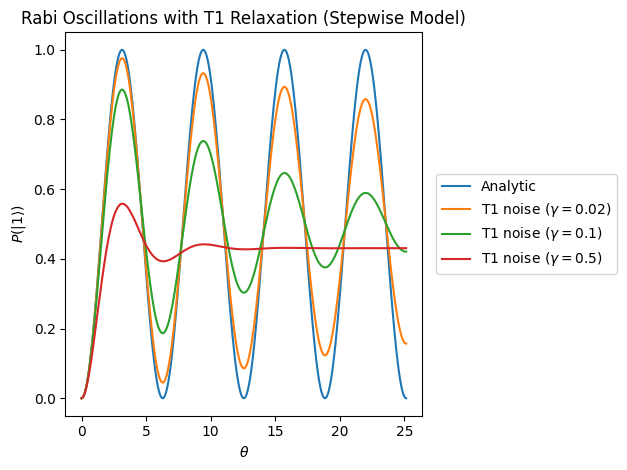

In [15]:
plt.figure()

plt.plot(thetas_multi_period, p1_analytic, label="Analytic")
for gamma in gamma_values_t1_stepwise:
    plt.plot(thetas_multi_period, p1_t1_stepwise[gamma], label=fr"T1 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T1 Relaxation (Stepwise Model)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

### Interpretation

In the stepwise model, T1 relaxation acts continuously during the driven evolution rather than only once at the end.

As a result, the oscillation is not only suppressed but also distorted by the repeated competition between excitation and relaxation. This provides a more realistic picture of driven open-system dynamics.

## T2 Dephasing: Stepwise Model

T2 dephasing describes loss of phase coherence without direct energy relaxation. In the circuit model, this effect is represented using a phase damping channel.

As in the stepwise T1 model, we divide the driven evolution into small steps. In each step, we apply a small rotation followed by phase damping with strength proportional to the step size. This lets dephasing accumulate during the driven evolution.

Unlike T1 relaxation, T2 dephasing does not directly drive the qubit toward the ground state. Instead, it reduces the coherence responsible for the oscillation, so the Rabi oscillations gradually lose contrast as the dephasing strength increases.

In [ ]:
gamma_values_t2 = [0.05, 0.1, 0.2]

p1_t2_stepwise = {
    gamma: np.array(
        [
            excited_state_probability(
                rabi_simulated_dynamics(theta, gamma_t2=gamma, dtheta=0.1),
                device_dm,
            )
            for theta in thetas_multi_period
        ]
    )
    for gamma in gamma_values_t2
}

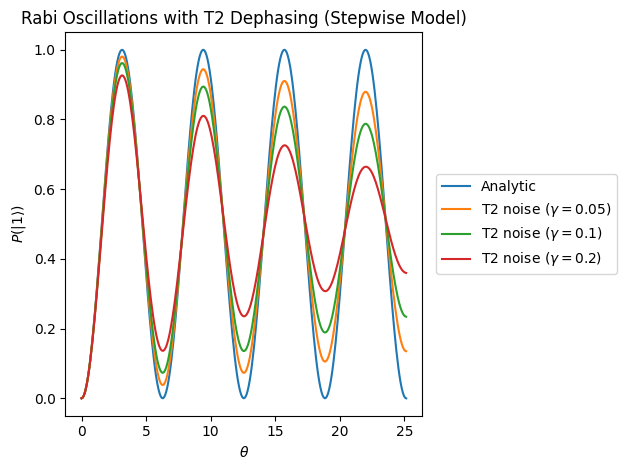

In [17]:
plt.figure()

plt.plot(thetas_multi_period, p1_analytic, label="Analytic")
for gamma in gamma_values_t2:
    plt.plot(thetas_multi_period, p1_t2_stepwise[gamma], label=fr"T2 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T2 Dephasing (Stepwise Model)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

### Interpretation

In the stepwise T2 model, the oscillations gradually lose contrast because phase coherence is lost during the driven evolution.

For weak dephasing, the oscillations remain close to the ideal curve. As the dephasing strength increases, the oscillations are progressively washed out, while the behavior remains distinct from T1 relaxation because T2 primarily destroys coherence rather than removing population from the excited state.

## Combined T1 and T2 Noise

So far we have considered T1 relaxation and T2 dephasing separately. In realistic quantum devices, both processes occur simultaneously.

We again use the stepwise approach. For each small step of the driven evolution, we apply a small rotation representing the drive, followed by amplitude damping for T1 relaxation and phase damping for T2 dephasing. This allows both energy relaxation and dephasing to act continuously during the Rabi oscillation.

When both T1 and T2 are present, the oscillations typically decay faster than with either process alone. T1 relaxation reduces the excited-state population, while T2 dephasing reduces the coherence responsible for the oscillations.

In [ ]:
gamma_t1 = 0.1
gamma_t2_values = [0.05, 0.1, 0.2]

p1_t1_t2_stepwise = {
    gamma_t2: np.array(
        [
            excited_state_probability(
                rabi_simulated_dynamics(
                    theta,
                    gamma_t1=gamma_t1,
                    gamma_t2=gamma_t2,
                    dtheta=0.1,
                ),
                device_dm,
            )
            for theta in thetas_multi_period
        ]
    )
    for gamma_t2 in gamma_t2_values
}

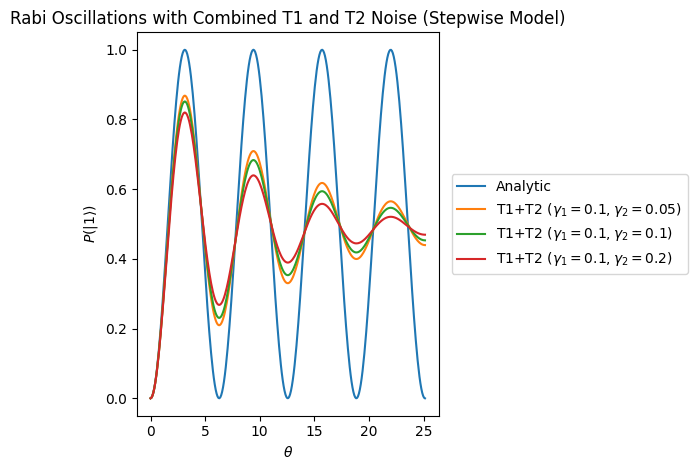

In [19]:
plt.figure()

plt.plot(thetas_multi_period, p1_analytic, label="Analytic")
for gamma_t2 in gamma_t2_values:
    plt.plot(
        thetas_multi_period,
        p1_t1_t2_stepwise[gamma_t2],
        label=fr"T1+T2 ($\gamma_1={gamma_t1}, \gamma_2={gamma_t2}$)",
    )

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with Combined T1 and T2 Noise (Stepwise Model)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

### Interpretation

With both T1 and T2 noise present, the Rabi oscillations decay more rapidly than in the individual noise cases. T1 relaxation reduces the excited-state population, while T2 dephasing reduces the coherence that drives the oscillations.

Together, these effects produce faster damping and a more realistic noisy Rabi signal.

## Off-Resonant Rabi Oscillations

So far we assumed the drive is resonant with the qubit transition. If the drive frequency is detuned, the qubit experiences both a coherent drive and phase accumulation.

In the circuit model, this corresponds to combining x-rotations from the drive with z-rotations from detuning. The combined evolution no longer acts like a pure x-rotation.

As a result, the oscillations no longer reach full population transfer. Increasing detuning reduces the maximum excitation probability and modifies the oscillation frequency.

The circuit model separates the driven dynamics into two effects:

| Physical effect | Parameter | Circuit operation |
|---|---:|---|
| Resonant drive | $\Omega$ | $R_x$ rotation |
| Detuning from resonance | $\Delta = \omega_d - \omega_0$ | $R_z$ rotation |
| Off-resonant drive | $\Omega$ and $\Delta$ | combined $R_x$ and $R_z$ rotations |

Here, $\omega_0$ is the qubit transition frequency, $\omega_d$ is the drive frequency, $\Omega$ is the resonant drive strength, and $\Delta$ is the detuning.

In [ ]:
delta_values = [0.0, 0.5, 1.0]

p1_off_resonant = {
    delta: np.array(
        [
            excited_state_probability(
                rabi_simulated_dynamics(theta, delta=delta, dtheta=0.1),
                device,
            )
            for theta in thetas_multi_period
        ]
    )
    for delta in delta_values
}

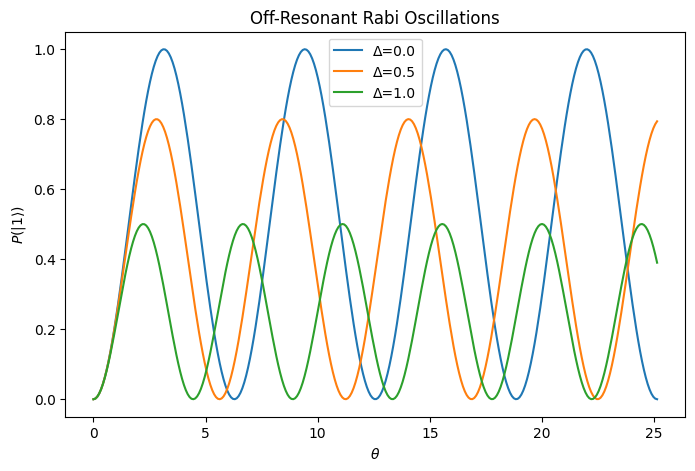

In [ ]:
plt.figure(figsize=(8, 5))
for delta in delta_values:
    plt.plot(thetas_multi_period, p1_off_resonant[delta], label=f"Δ={delta}")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Off-Resonant Rabi Oscillations")
plt.legend()
plt.show()

### Interpretation

For zero detuning, the oscillations reach full population transfer. As the detuning increases, the oscillations no longer reach probability 1 and the dynamics change.

This reflects rotation around a tilted axis: detuning introduces phase accumulation, which reduces the efficiency of population transfer.

## Off-Resonant Rabi Oscillations with T1 and T2 Noise

Finally, we combine detuning with relaxation and dephasing. In this model, the qubit evolves with an off-resonant drive while also undergoing amplitude damping (T1) and phase damping (T2).

This combines the coherent effect of detuning with the incoherent noise processes introduced above.

In [ ]:
delta = 0.5
gamma_t1 = 0.1
gamma_t2 = 0.1

p1_off_resonant_t1_t2 = np.array(
    [
        excited_state_probability(
            rabi_simulated_dynamics(
                theta,
                delta=delta,
                gamma_t1=gamma_t1,
                gamma_t2=gamma_t2,
                dtheta=0.1,
            ),
            device_dm,
        )
        for theta in thetas_multi_period
    ]
)

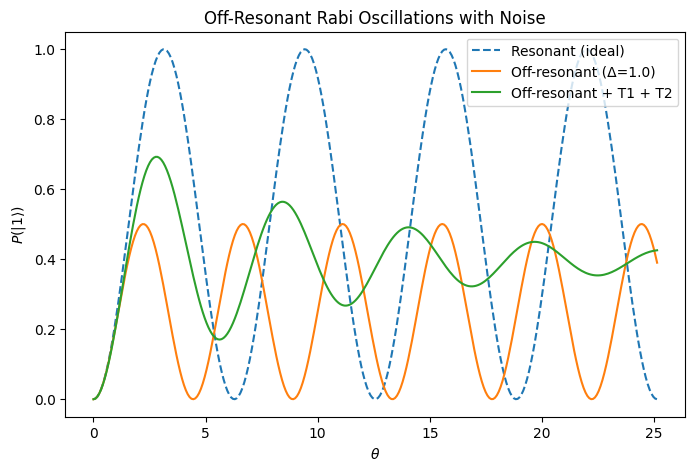

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(thetas_multi_period, p1_off_resonant[0.0], label="Resonant (ideal)", linestyle="--")
plt.plot(thetas_multi_period, p1_off_resonant[delta], label=f"Off-resonant (Δ={delta})")
plt.plot(thetas_multi_period, p1_off_resonant_t1_t2, label="Off-resonant + T1 + T2")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Off-Resonant Rabi Oscillations with Noise")
plt.legend()
plt.show()

### Interpretation

The addition of T1 and T2 noise leads to a decay of the oscillations over time. Compared to the purely off-resonant case, the amplitude decreases further and the oscillations gradually disappear due to relaxation and dephasing.

This combined model illustrates how coherent effects such as detuning and incoherent noise processes together determine the observed qubit dynamics.